# Histogram Processing in Image Processing

This notebook is a complete, practical guide to histogram processing.
You will learn what histograms are, how to compute and interpret them,
and how to use them to improve image quality.

## What you will learn
1. Histogram basics (grayscale and color)
2. Normalized histogram and CDF
3. Intensity transforms (brightness, contrast, gamma)
4. Contrast stretching
5. Global histogram equalization
6. Adaptive histogram equalization (simple CLAHE idea)
7. Histogram matching (specification)
8. Otsu thresholding from histogram
9. 2D color histograms
10. A practical enhancement workflow

All code is written step by step with explanations.

## How to use this notebook

- Run cells from top to bottom.
- If you have images in `images/`, the notebook will use them.
- If no image is found, synthetic demo images will be generated automatically.
- Read the markdown before each code block, then run and inspect the plots.

In [ ]:
from pathlib import Path #this will help us to read the image from the path and also to save the processed image in the same path with a different name
import numpy as np #this will help us to perform mathematical operations on the image and also to create histograms
import matplotlib.pyplot as plt #this will help us to visualize the histograms and also to display the images
from PIL import Image #this will help us to read the image and also to save the processed image
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
#this will help us to convert the image from RGB to HSV and also from HSV to RGB

plt.style.use("seaborn-v0_8-whitegrid")
#this will help us to set the style of the plots to seaborn whitegrid
np.random.seed(7)#this will help us to set the random seed to 7 for reproducibility

In [16]:
PROJECT_ROOT = Path.cwd() #this will help us to set the project root directory to the current working directory
IMAGE_DIR = PROJECT_ROOT / "images" #this will help us to set the image directory to the "images" folder in the project root directory
SUPPORTED_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}#this will help us to define the supported image file extensions

def list_image_files(image_dir=IMAGE_DIR):#this function will help us to list all the image files in the given image directory and also to filter out the files that are not images based on the supported file extensions
    if not image_dir.exists():
        return []
    return sorted(
        [p for p in image_dir.iterdir() if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS]
    )

def load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

def rgb_to_gray(rgb):
    r = rgb[..., 0].astype(np.float32)
    g = rgb[..., 1].astype(np.float32)
    b = rgb[..., 2].astype(np.float32)
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    return np.clip(gray, 0, 255).astype(np.uint8)

def compute_histogram(gray):
    return np.bincount(gray.ravel(), minlength=256)

def normalized_histogram(gray):
    hist = compute_histogram(gray).astype(np.float64)
    return hist / hist.sum()

def cdf_from_hist(hist):
    cdf = np.cumsum(hist)
    if cdf[-1] == 0:
        return cdf
    return cdf / cdf[-1]

def show_image(img, title="", cmap=None, vmin=None, vmax=None):
    plt.figure(figsize=(6, 4))
    plt.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def show_gray_with_hist(gray, title=""):
    hist = compute_histogram(gray)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
    ax[0].set_title(title if title else "Grayscale image")
    ax[0].axis("off")

    ax[1].plot(hist, color="black", linewidth=1.8)
    ax[1].set_title("Histogram")
    ax[1].set_xlabel("Intensity (0-255)")
    ax[1].set_ylabel("Pixel count")
    ax[1].set_xlim(0, 255)

    plt.tight_layout()
    plt.show()

## Load a sample image

This cell picks an image from `images/`. If no image exists, it builds a synthetic image so all later cells still work.

Using image: c:\Users\hp\OneDrive\Desktop\projects\image_processing\images\analysis_dashboard.png


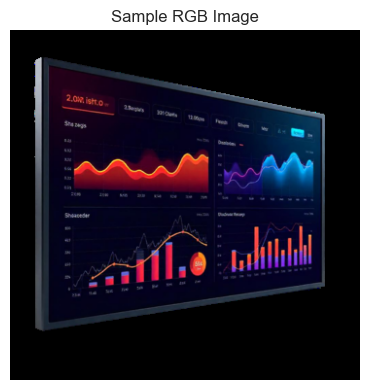

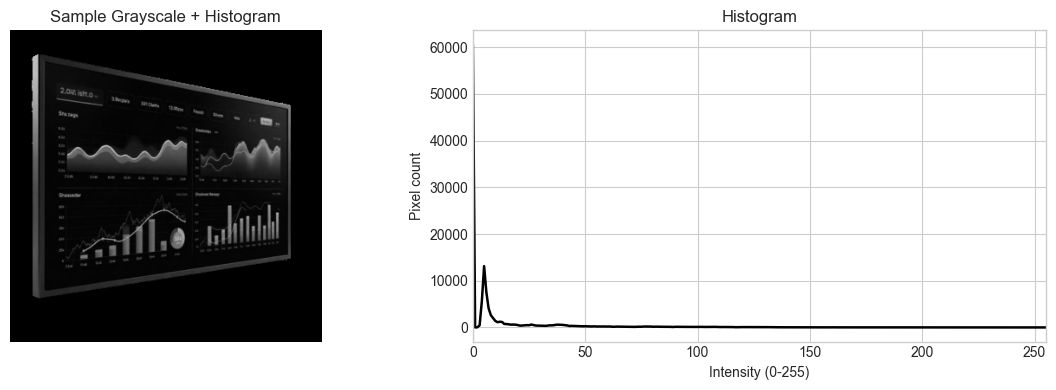

In [3]:
image_files = list_image_files()

if image_files:
    sample_path = image_files[0]
    sample_rgb = load_rgb(sample_path)
    sample_gray = rgb_to_gray(sample_rgb)
    print(f"Using image: {sample_path}")
else:
    sample_path = None
    # Synthetic fallback image: horizontal gradient with a bright square
    g = np.tile(np.arange(256, dtype=np.uint8), (256, 1))
    synthetic = g.copy()
    synthetic[80:176, 80:176] = 220
    sample_gray = synthetic
    sample_rgb = np.dstack([sample_gray] * 3)
    print("No image file found in ./images. Using synthetic image.")

show_image(sample_rgb, "Sample RGB Image")
show_gray_with_hist(sample_gray, "Sample Grayscale + Histogram")

## 1) Histogram Basics

A grayscale histogram is a frequency count of intensity values:
- `x` axis: intensity level (0 = black, 255 = white)
- `y` axis: number of pixels at that level

How to read shape quickly:
- Left-heavy histogram: dark image
- Right-heavy histogram: bright image
- Narrow center peak: low contrast
- Wide spread: high contrast
- Two major peaks: bimodal intensity distribution

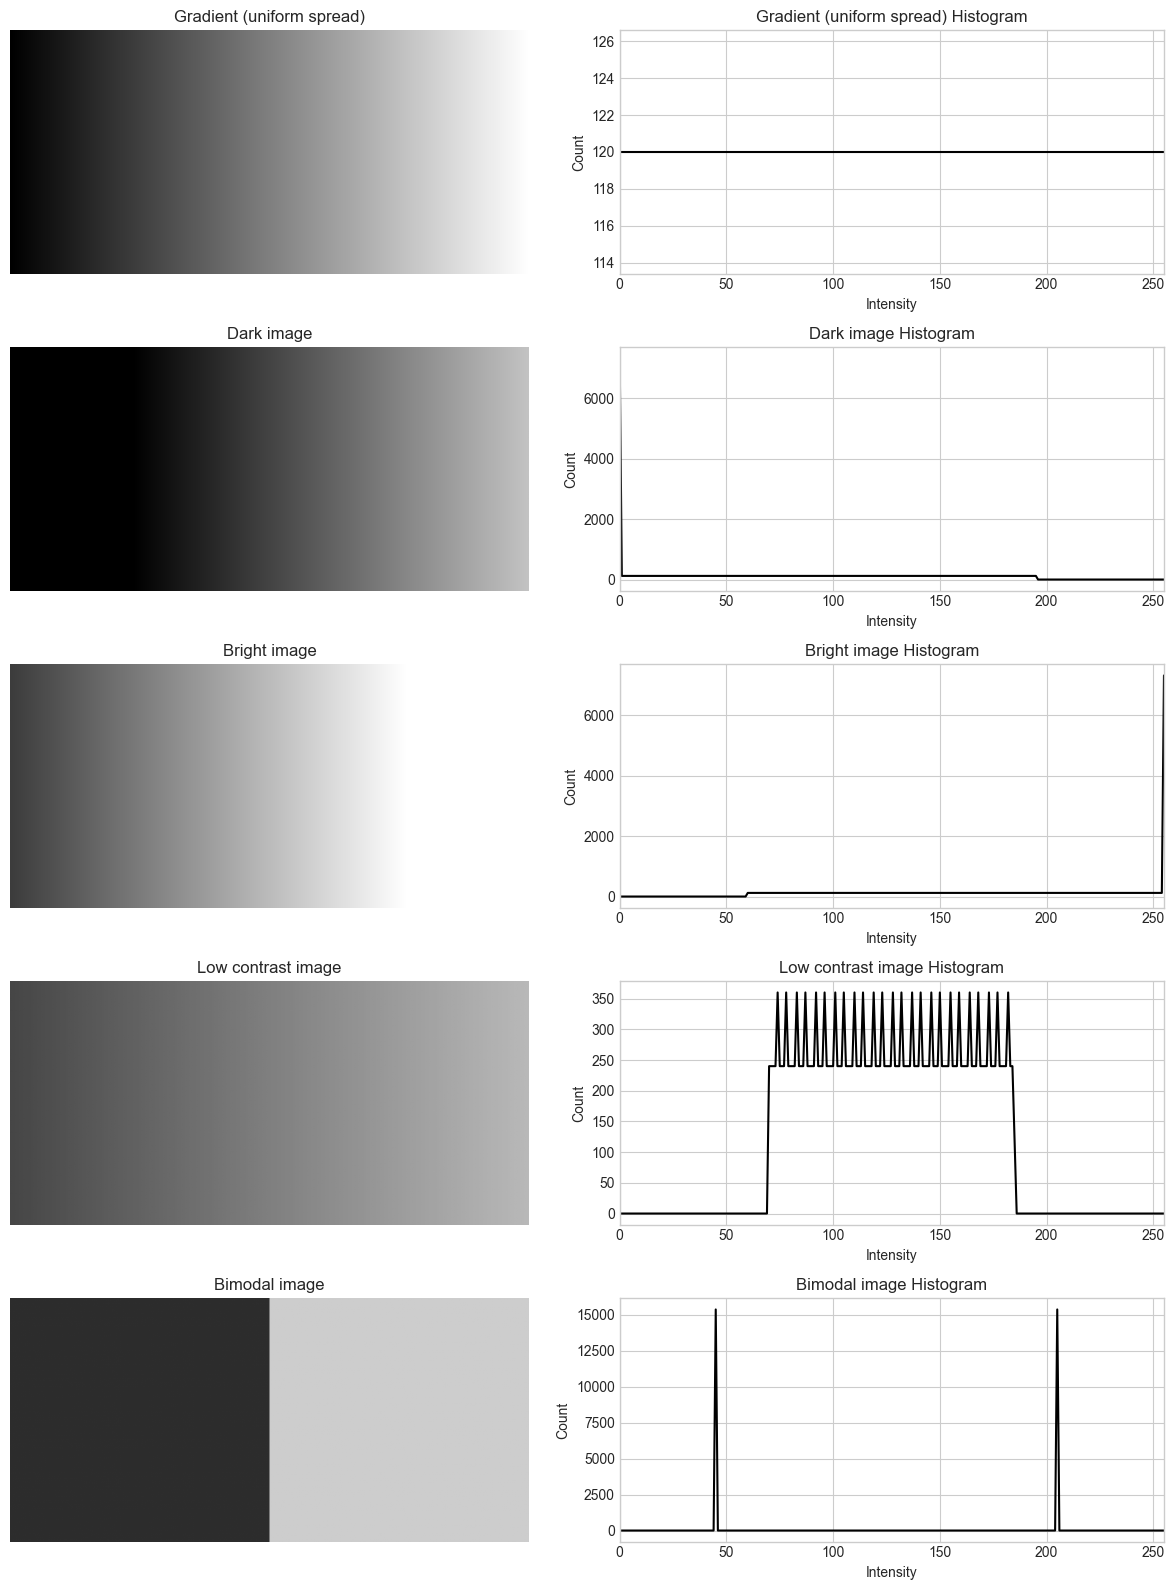

In [4]:
gradient = np.tile(np.arange(256, dtype=np.uint8), (120, 1))
dark = np.clip(gradient.astype(np.int16) - 60, 0, 255).astype(np.uint8)
bright = np.clip(gradient.astype(np.int16) + 60, 0, 255).astype(np.uint8)
low_contrast = np.clip((gradient.astype(np.float32) - 128) * 0.45 + 128, 0, 255).astype(np.uint8)
bimodal = np.zeros((120, 256), dtype=np.uint8)
bimodal[:, :128] = 45
bimodal[:, 128:] = 205

examples = [
    ("Gradient (uniform spread)", gradient),
    ("Dark image", dark),
    ("Bright image", bright),
    ("Low contrast image", low_contrast),
    ("Bimodal image", bimodal),
]

fig, axes = plt.subplots(len(examples), 2, figsize=(12, 16))
for i, (name, img) in enumerate(examples):
    hist = compute_histogram(img)
    axes[i, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[i, 0].set_title(name)
    axes[i, 0].axis("off")

    axes[i, 1].plot(hist, color="black")
    axes[i, 1].set_xlim(0, 255)
    axes[i, 1].set_title(f"{name} Histogram")
    axes[i, 1].set_xlabel("Intensity")
    axes[i, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 2) Compute Histogram Manually

A histogram is simple counting.
This helps you understand that every advanced method starts with a basic count of pixel values.

Manual and np.bincount are equal: True
Total pixels: 129600
Histogram sum: 129600


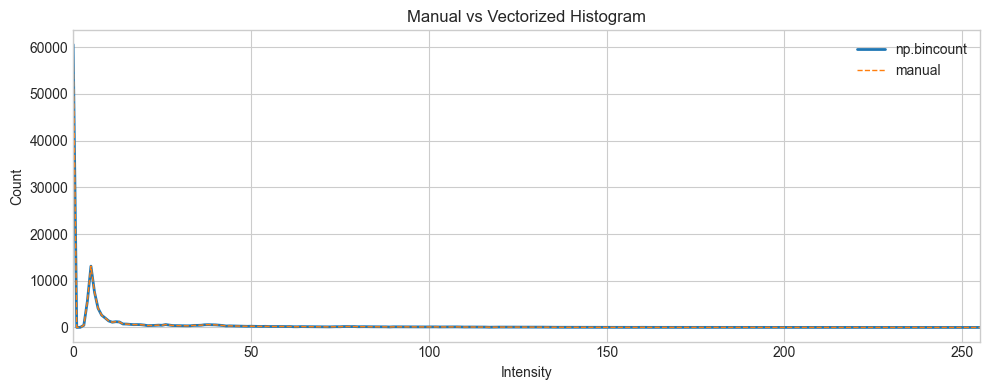

In [5]:
def histogram_manual(gray):
    hist = np.zeros(256, dtype=np.int64)
    flat = gray.ravel()
    for value in flat:
        hist[int(value)] += 1
    return hist

manual_hist = histogram_manual(sample_gray)
fast_hist = compute_histogram(sample_gray)

print("Manual and np.bincount are equal:", np.array_equal(manual_hist, fast_hist))
print("Total pixels:", sample_gray.size)
print("Histogram sum:", fast_hist.sum())

plt.figure(figsize=(10, 4))
plt.plot(fast_hist, label="np.bincount", linewidth=2)
plt.plot(manual_hist, "--", label="manual", linewidth=1)
plt.xlim(0, 255)
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.title("Manual vs Vectorized Histogram")
plt.legend()
plt.tight_layout()
plt.show()

## 3) Normalized Histogram (PDF) and CDF

- **PDF** (probability density function): histogram divided by total pixel count.
- **CDF** (cumulative distribution function): running sum of the PDF.

CDF is central to equalization and histogram matching.

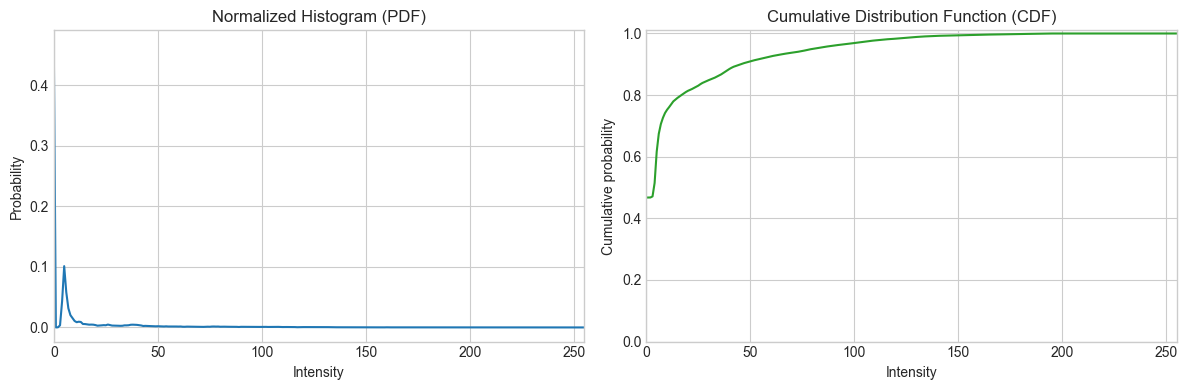

CDF first value: 0.4675
CDF last value : 1.0000 (should be 1.0)


In [6]:
hist = compute_histogram(sample_gray).astype(np.float64)
pdf = hist / hist.sum()
cdf = np.cumsum(pdf)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(pdf, color="tab:blue")
ax[0].set_title("Normalized Histogram (PDF)")
ax[0].set_xlabel("Intensity")
ax[0].set_ylabel("Probability")
ax[0].set_xlim(0, 255)

ax[1].plot(cdf, color="tab:green")
ax[1].set_title("Cumulative Distribution Function (CDF)")
ax[1].set_xlabel("Intensity")
ax[1].set_ylabel("Cumulative probability")
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 1.01)

plt.tight_layout()
plt.show()

print(f"CDF first value: {cdf[0]:.4f}")
print(f"CDF last value : {cdf[-1]:.4f} (should be 1.0)")

## 4) Intensity Transforms

Histogram shape changes when you transform pixel intensities.
Common transforms:
- Brightness shift
- Contrast scaling
- Gamma correction (non-linear)

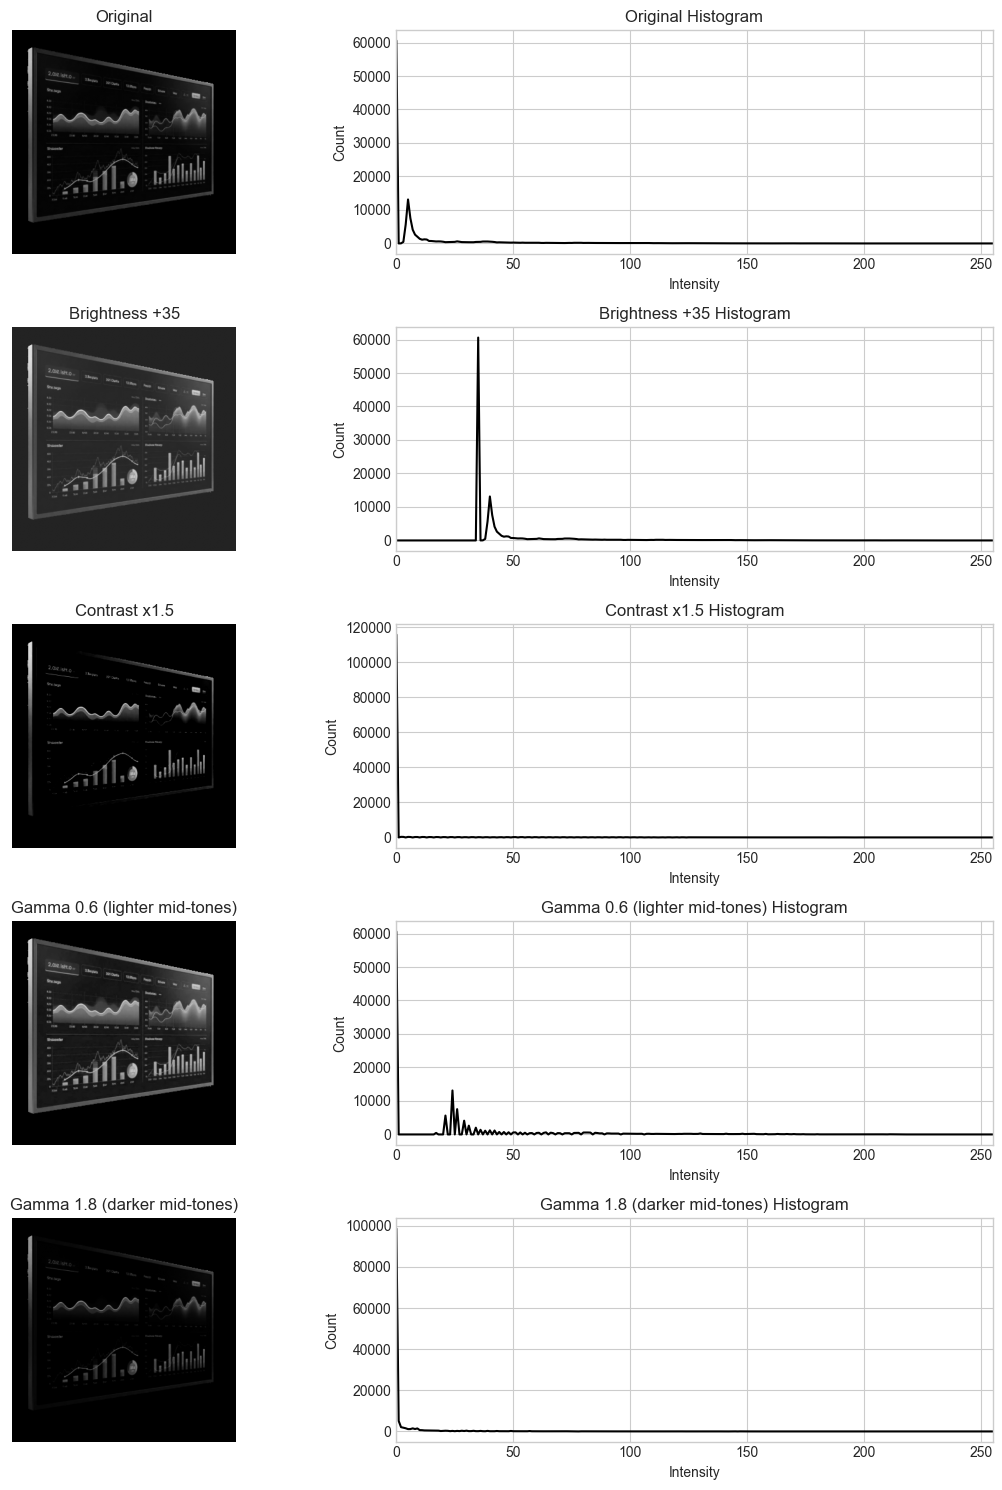

In [7]:
def adjust_brightness(gray, delta):
    return np.clip(gray.astype(np.int16) + delta, 0, 255).astype(np.uint8)

def adjust_contrast(gray, factor, midpoint=128):
    transformed = (gray.astype(np.float32) - midpoint) * factor + midpoint
    return np.clip(transformed, 0, 255).astype(np.uint8)

def gamma_correction(gray, gamma):
    x = gray.astype(np.float32) / 255.0
    y = np.power(x, gamma)
    return np.clip(y * 255.0, 0, 255).astype(np.uint8)

brighter = adjust_brightness(sample_gray, 35)
higher_contrast = adjust_contrast(sample_gray, 1.5)
gamma_light = gamma_correction(sample_gray, 0.6)
gamma_dark = gamma_correction(sample_gray, 1.8)

variants = [
    ("Original", sample_gray),
    ("Brightness +35", brighter),
    ("Contrast x1.5", higher_contrast),
    ("Gamma 0.6 (lighter mid-tones)", gamma_light),
    ("Gamma 1.8 (darker mid-tones)", gamma_dark),
]

fig, axes = plt.subplots(len(variants), 2, figsize=(12, 15))
for i, (name, img) in enumerate(variants):
    axes[i, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[i, 0].set_title(name)
    axes[i, 0].axis("off")

    axes[i, 1].plot(compute_histogram(img), color="black")
    axes[i, 1].set_xlim(0, 255)
    axes[i, 1].set_title(f"{name} Histogram")
    axes[i, 1].set_xlabel("Intensity")
    axes[i, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 5) Contrast Stretching

Contrast stretching expands a narrow intensity range to use a wider output range.

Two common variants:
1. **Min-Max stretch**: uses global min and max
2. **Percentile stretch**: ignores outliers (more robust)

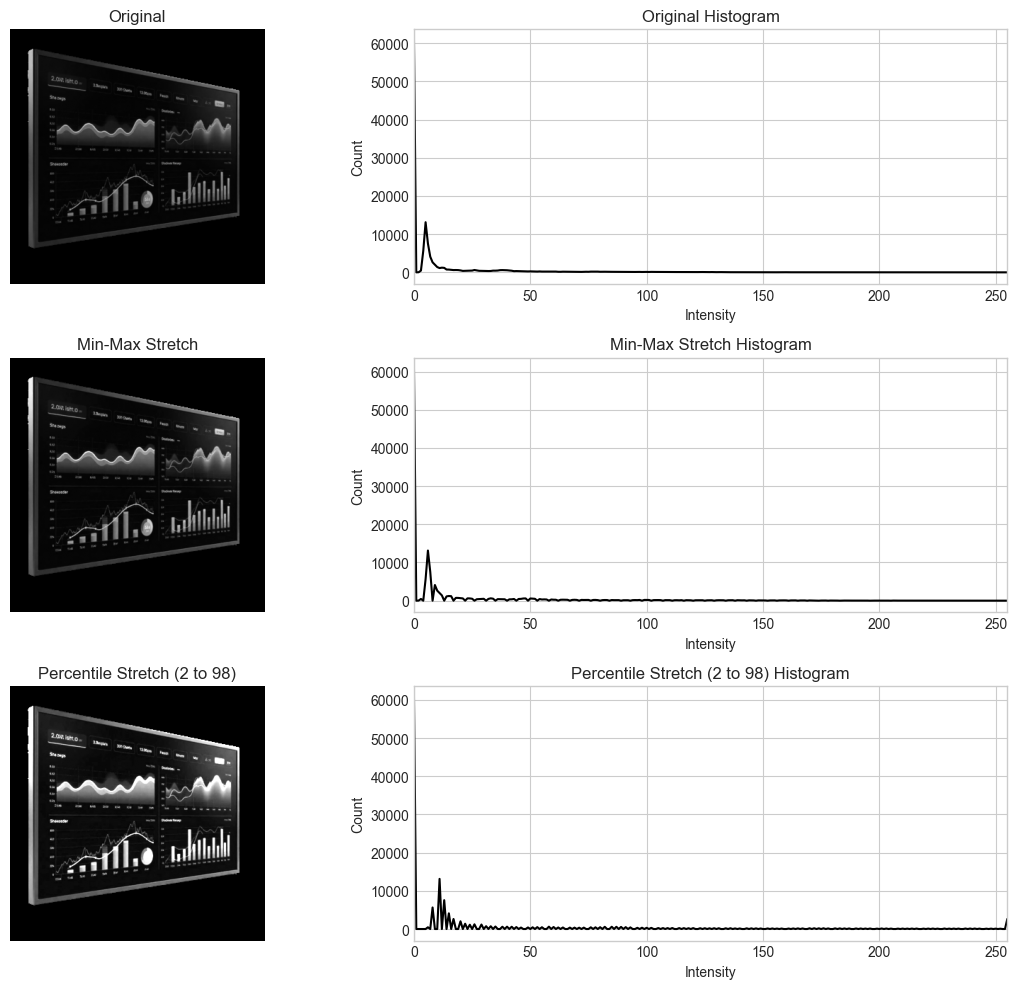

In [8]:
def contrast_stretch_minmax(gray):
    g = gray.astype(np.float32)
    g_min = g.min()
    g_max = g.max()
    if g_max == g_min:
        return np.zeros_like(gray)
    stretched = (g - g_min) * (255.0 / (g_max - g_min))
    return np.clip(stretched, 0, 255).astype(np.uint8)

def contrast_stretch_percentile(gray, p_low=2, p_high=98):
    g = gray.astype(np.float32)
    low = np.percentile(g, p_low)
    high = np.percentile(g, p_high)
    if high <= low:
        return gray.copy()
    stretched = (g - low) * (255.0 / (high - low))
    return np.clip(stretched, 0, 255).astype(np.uint8)

stretched_minmax = contrast_stretch_minmax(sample_gray)
stretched_pct = contrast_stretch_percentile(sample_gray, 2, 98)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i, (name, img) in enumerate([
    ("Original", sample_gray),
    ("Min-Max Stretch", stretched_minmax),
    ("Percentile Stretch (2 to 98)", stretched_pct),
]):
    axes[i, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[i, 0].set_title(name)
    axes[i, 0].axis("off")

    axes[i, 1].plot(compute_histogram(img), color="black")
    axes[i, 1].set_xlim(0, 255)
    axes[i, 1].set_title(f"{name} Histogram")
    axes[i, 1].set_xlabel("Intensity")
    axes[i, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 6) Global Histogram Equalization

Idea: remap intensities using the CDF so the output uses more of the available range.

Typical effect:
- Better global contrast
- May over-enhance noise or wash out local details in some images

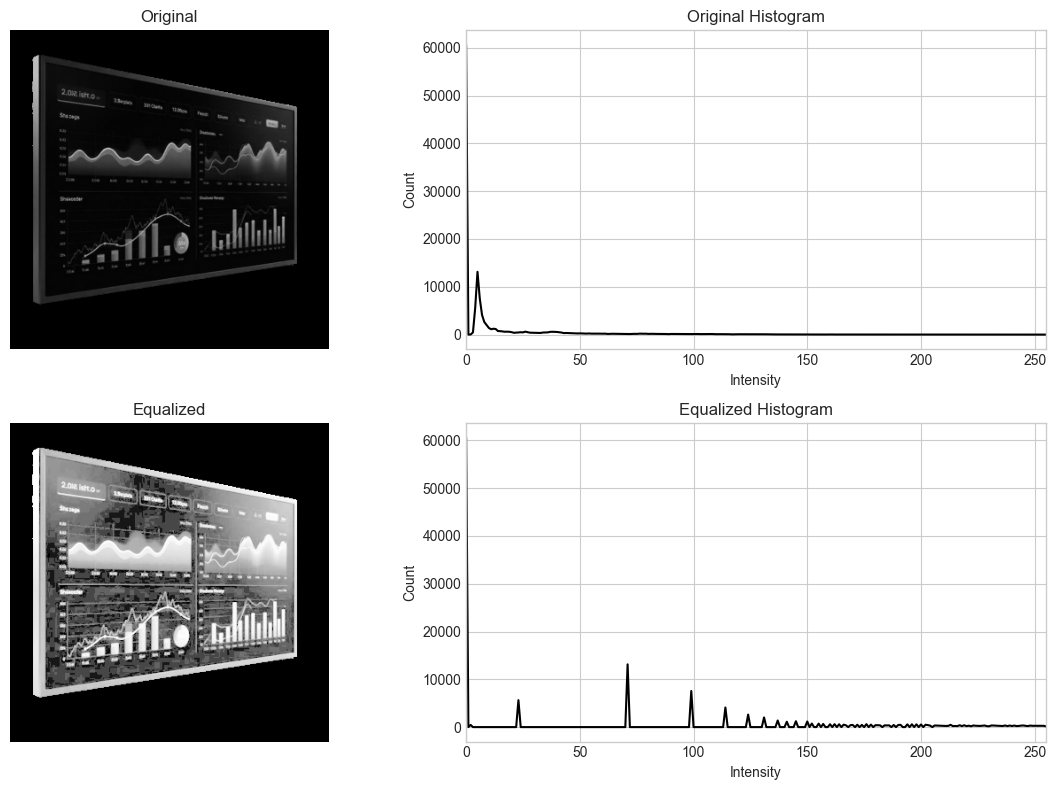

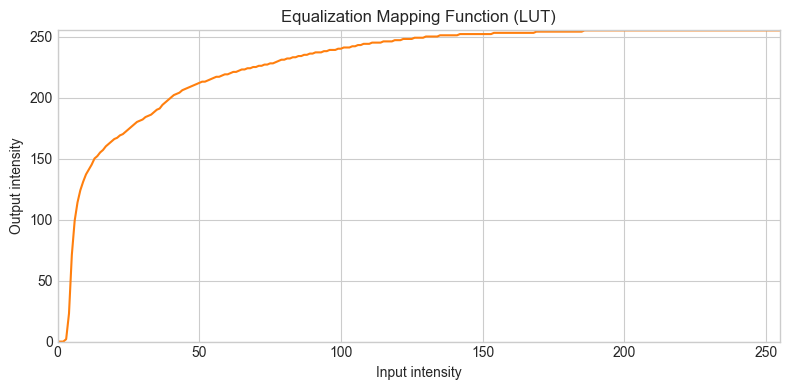

In [9]:
def histogram_equalization(gray):
    hist = compute_histogram(gray).astype(np.float64)
    cdf = np.cumsum(hist)

    nonzero = np.nonzero(hist)[0]
    if len(nonzero) == 0:
        return gray.copy(), np.arange(256, dtype=np.uint8)

    cdf_min = cdf[nonzero[0]]
    total = cdf[-1]
    lut = np.round((cdf - cdf_min) / (total - cdf_min + 1e-12) * 255.0)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    equalized = lut[gray]
    return equalized, lut

equalized, lut_eq = histogram_equalization(sample_gray)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(sample_gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].plot(compute_histogram(sample_gray), color="black")
axes[0, 1].set_title("Original Histogram")
axes[0, 1].set_xlim(0, 255)
axes[0, 1].set_xlabel("Intensity")
axes[0, 1].set_ylabel("Count")

axes[1, 0].imshow(equalized, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Equalized")
axes[1, 0].axis("off")

axes[1, 1].plot(compute_histogram(equalized), color="black")
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlim(0, 255)
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lut_eq, color="tab:orange")
plt.title("Equalization Mapping Function (LUT)")
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.tight_layout()
plt.show()

## 7) Adaptive Histogram Equalization (Simple CLAHE-style)

Global equalization uses one mapping for the whole image.
Adaptive methods build local mappings tile by tile.

The implementation below is a **simple CLAHE-style version**:
- Splits image into tiles
- Clips high histogram bins
- Redistributes excess counts
- Equalizes each tile separately

Note: production CLAHE uses interpolation between tiles to reduce block artifacts.

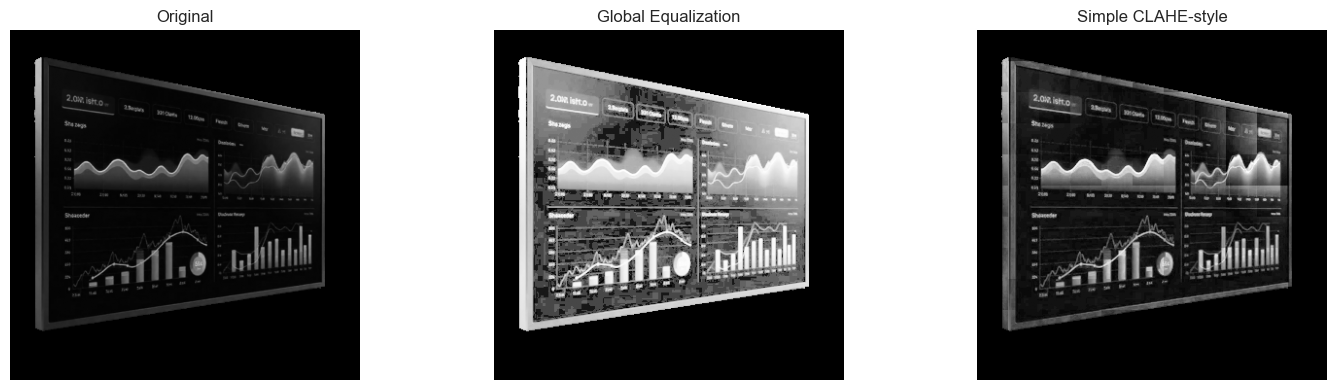

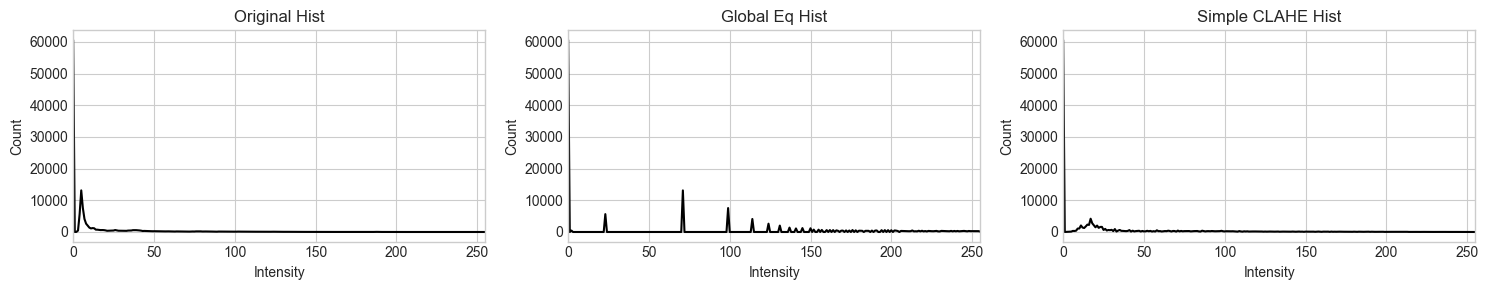

In [10]:
def simple_clahe(gray, tile_size=32, clip_limit=0.02):
    h, w = gray.shape
    out = np.zeros_like(gray)

    for y0 in range(0, h, tile_size):
        for x0 in range(0, w, tile_size):
            tile = gray[y0:y0 + tile_size, x0:x0 + tile_size]
            n = tile.size
            clip_count = max(1, int(clip_limit * n))

            hist = np.bincount(tile.ravel(), minlength=256).astype(np.float64)
            excess = np.maximum(hist - clip_count, 0.0)
            hist = np.minimum(hist, clip_count)

            # Redistribute clipped counts uniformly across bins
            hist += excess.sum() / 256.0

            cdf = np.cumsum(hist)
            cdf = (cdf - cdf.min()) / (cdf.max() - cdf.min() + 1e-12)
            lut = np.clip(np.round(cdf * 255.0), 0, 255).astype(np.uint8)

            out[y0:y0 + tile_size, x0:x0 + tile_size] = lut[tile]

    return out

clahe_like = simple_clahe(sample_gray, tile_size=32, clip_limit=0.02)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(sample_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(equalized, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Global Equalization")
axes[1].axis("off")

axes[2].imshow(clahe_like, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Simple CLAHE-style")
axes[2].axis("off")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].plot(compute_histogram(sample_gray), color="black")
ax[0].set_title("Original Hist")
ax[1].plot(compute_histogram(equalized), color="black")
ax[1].set_title("Global Eq Hist")
ax[2].plot(compute_histogram(clahe_like), color="black")
ax[2].set_title("Simple CLAHE Hist")
for a in ax:
    a.set_xlim(0, 255)
    a.set_xlabel("Intensity")
    a.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 8) Color Histograms

For RGB images, each channel has its own histogram.

Important practice:
- Equalizing each channel independently can change colors.
- Often better: convert to a color space and enhance only brightness/value channel.

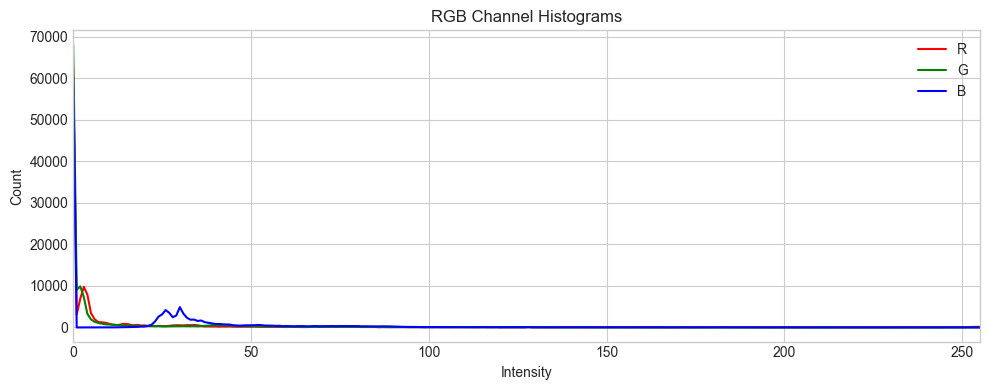

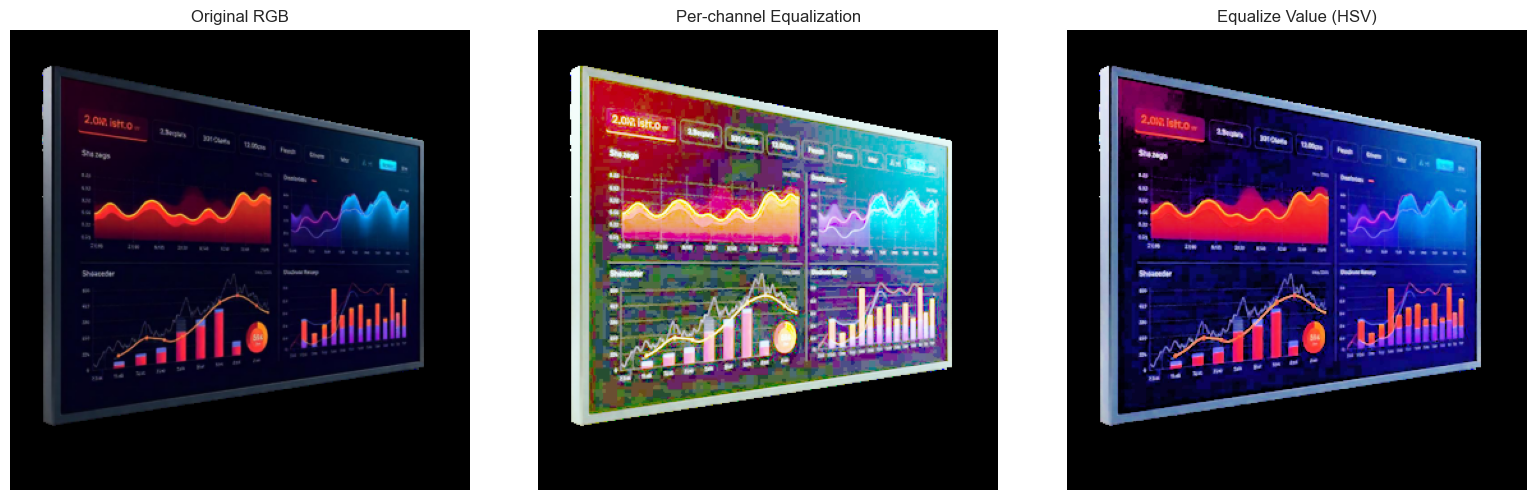

In [11]:
def color_histograms(rgb):
    hist_r = np.bincount(rgb[..., 0].ravel(), minlength=256)
    hist_g = np.bincount(rgb[..., 1].ravel(), minlength=256)
    hist_b = np.bincount(rgb[..., 2].ravel(), minlength=256)
    return hist_r, hist_g, hist_b

hist_r, hist_g, hist_b = color_histograms(sample_rgb)

plt.figure(figsize=(10, 4))
plt.plot(hist_r, color="red", label="R")
plt.plot(hist_g, color="green", label="G")
plt.plot(hist_b, color="blue", label="B")
plt.title("RGB Channel Histograms")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.xlim(0, 255)
plt.legend()
plt.tight_layout()
plt.show()

# Naive channel-wise equalization (can shift colors)
naive_eq = np.stack(
    [histogram_equalization(sample_rgb[..., c])[0] for c in range(3)], axis=-1
)

# Better practice: equalize only brightness in HSV
rgb_float = sample_rgb.astype(np.float32) / 255.0
hsv = rgb_to_hsv(rgb_float)
v = np.clip(np.round(hsv[..., 2] * 255.0), 0, 255).astype(np.uint8)
v_eq, _ = histogram_equalization(v)
hsv_eq = hsv.copy()
hsv_eq[..., 2] = v_eq.astype(np.float32) / 255.0
value_eq_rgb = np.clip(hsv_to_rgb(hsv_eq) * 255.0, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(sample_rgb)
axes[0].set_title("Original RGB")
axes[0].axis("off")

axes[1].imshow(naive_eq)
axes[1].set_title("Per-channel Equalization")
axes[1].axis("off")

axes[2].imshow(value_eq_rgb)
axes[2].set_title("Equalize Value (HSV)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 9) Histogram Matching (Specification)

Goal: transform a source image so its histogram follows a reference image histogram.

This is useful when you want one image to look like another in terms of intensity distribution.

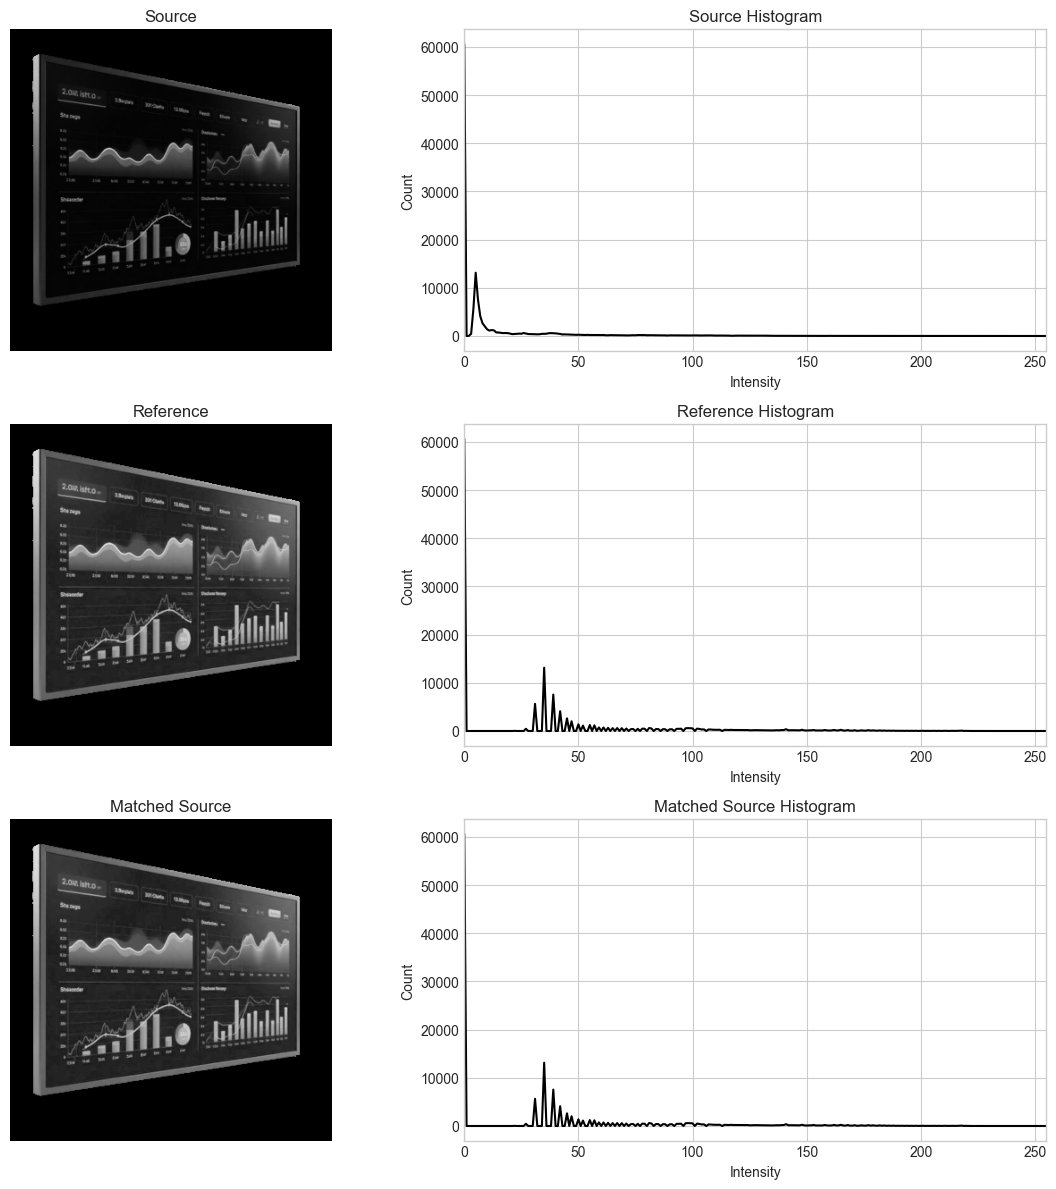

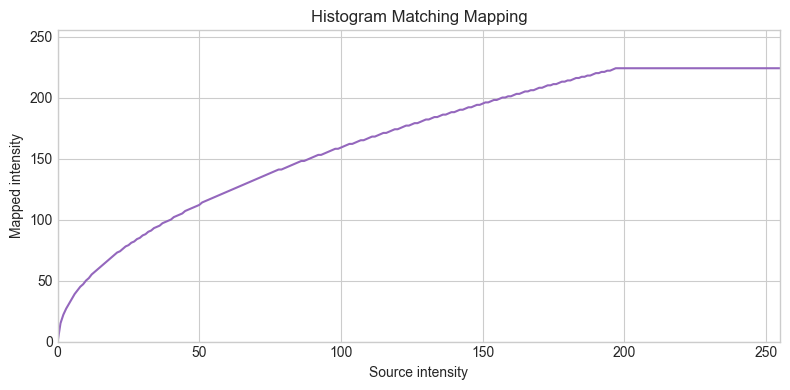

In [12]:
def histogram_match(source, reference):
    src_hist = compute_histogram(source).astype(np.float64)
    ref_hist = compute_histogram(reference).astype(np.float64)

    src_cdf = np.cumsum(src_hist) / src_hist.sum()
    ref_cdf = np.cumsum(ref_hist) / ref_hist.sum()

    mapping = np.zeros(256, dtype=np.uint8)
    ref_idx = 0
    for src_idx in range(256):
        while ref_idx < 255 and ref_cdf[ref_idx] < src_cdf[src_idx]:
            ref_idx += 1
        mapping[src_idx] = ref_idx

    matched = mapping[source]
    return matched, mapping

reference = gamma_correction(sample_gray, 0.5)
matched, mapping = histogram_match(sample_gray, reference)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
rows = [
    ("Source", sample_gray),
    ("Reference", reference),
    ("Matched Source", matched),
]
for i, (name, img) in enumerate(rows):
    axes[i, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[i, 0].set_title(name)
    axes[i, 0].axis("off")

    axes[i, 1].plot(compute_histogram(img), color="black")
    axes[i, 1].set_xlim(0, 255)
    axes[i, 1].set_title(f"{name} Histogram")
    axes[i, 1].set_xlabel("Intensity")
    axes[i, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(mapping, color="tab:purple")
plt.title("Histogram Matching Mapping")
plt.xlabel("Source intensity")
plt.ylabel("Mapped intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.tight_layout()
plt.show()

## 10) Otsu Thresholding from Histogram

Otsu picks a threshold that maximizes between-class variance
(background vs foreground) based on histogram statistics.

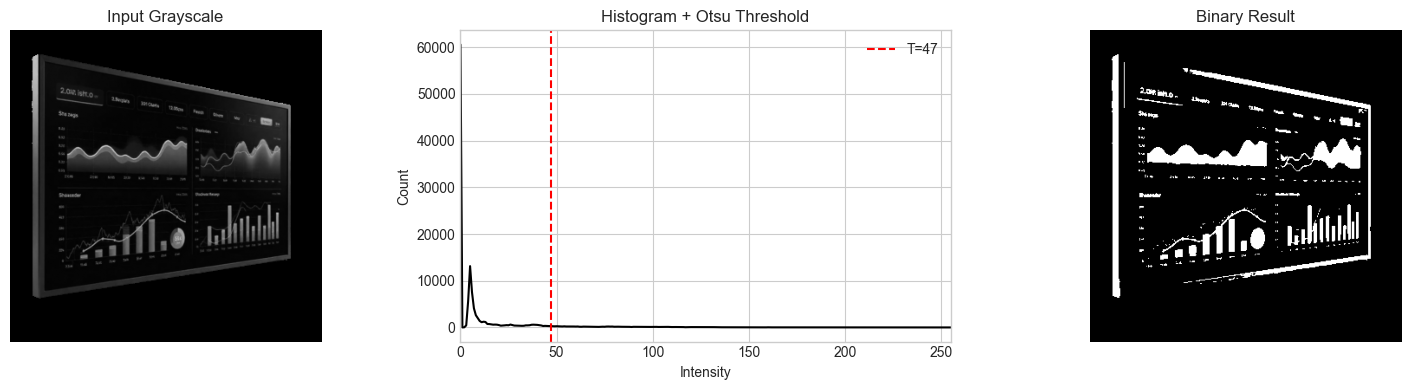

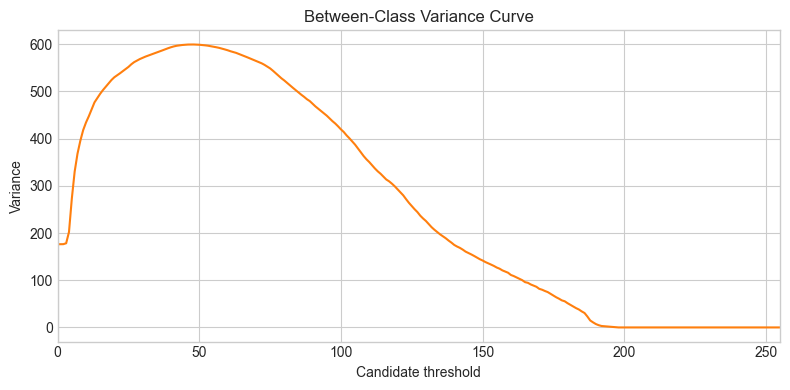

In [13]:
def otsu_threshold(gray):
    hist = compute_histogram(gray).astype(np.float64)
    total = gray.size
    prob = hist / total

    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))
    mu_t = mu[-1]

    sigma_b_sq = (mu_t * omega - mu) ** 2 / (omega * (1.0 - omega) + 1e-12)
    threshold = int(np.argmax(sigma_b_sq))
    binary = (gray >= threshold).astype(np.uint8) * 255
    return threshold, binary, sigma_b_sq

threshold, binary, sigma_curve = otsu_threshold(sample_gray)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(sample_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Input Grayscale")
axes[0].axis("off")

axes[1].plot(compute_histogram(sample_gray), color="black")
axes[1].axvline(threshold, color="red", linestyle="--", label=f"T={threshold}")
axes[1].set_title("Histogram + Otsu Threshold")
axes[1].set_xlim(0, 255)
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Count")
axes[1].legend()

axes[2].imshow(binary, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Binary Result")
axes[2].axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(sigma_curve, color="tab:orange")
plt.title("Between-Class Variance Curve")
plt.xlabel("Candidate threshold")
plt.ylabel("Variance")
plt.xlim(0, 255)
plt.tight_layout()
plt.show()

## 11) 2D Color Histogram

A 2D histogram captures joint channel behavior (example: Red vs Green).
This is useful for color-based analysis and segmentation.

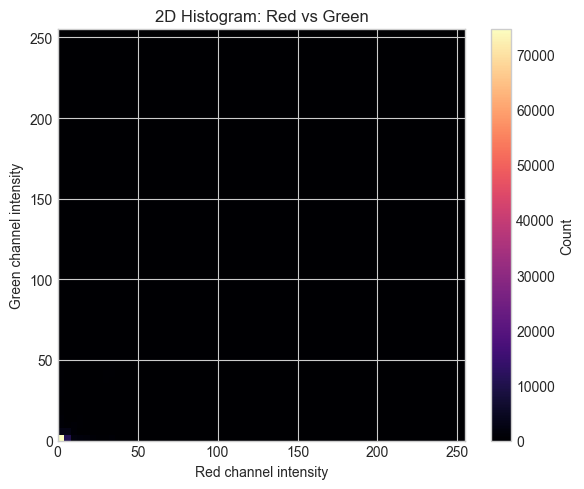

In [14]:
rg_hist, r_edges, g_edges = np.histogram2d(
    sample_rgb[..., 0].ravel(),
    sample_rgb[..., 1].ravel(),
    bins=64,
    range=[[0, 256], [0, 256]],
)

plt.figure(figsize=(6, 5))
plt.imshow(
    rg_hist.T,
    origin="lower",
    cmap="magma",
    extent=[0, 255, 0, 255],
    aspect="auto",
)
plt.colorbar(label="Count")
plt.xlabel("Red channel intensity")
plt.ylabel("Green channel intensity")
plt.title("2D Histogram: Red vs Green")
plt.tight_layout()
plt.show()

## 12) Practical Enhancement Workflow

There is no single best method for all images.
A good workflow is to try a few methods and compare simple quality indicators.

Quality indicators (higher is not always better, but useful for comparison):
Original             | RMS contrast:   28.28 | Entropy:  3.906
Equalized            | RMS contrast:   83.18 | Entropy:  3.783
Simple CLAHE-style   | RMS contrast:   47.45 | Entropy:  4.632
Percentile Stretch   | RMS contrast:   57.76 | Entropy:  3.783

Highest RMS contrast in this demo: Equalized


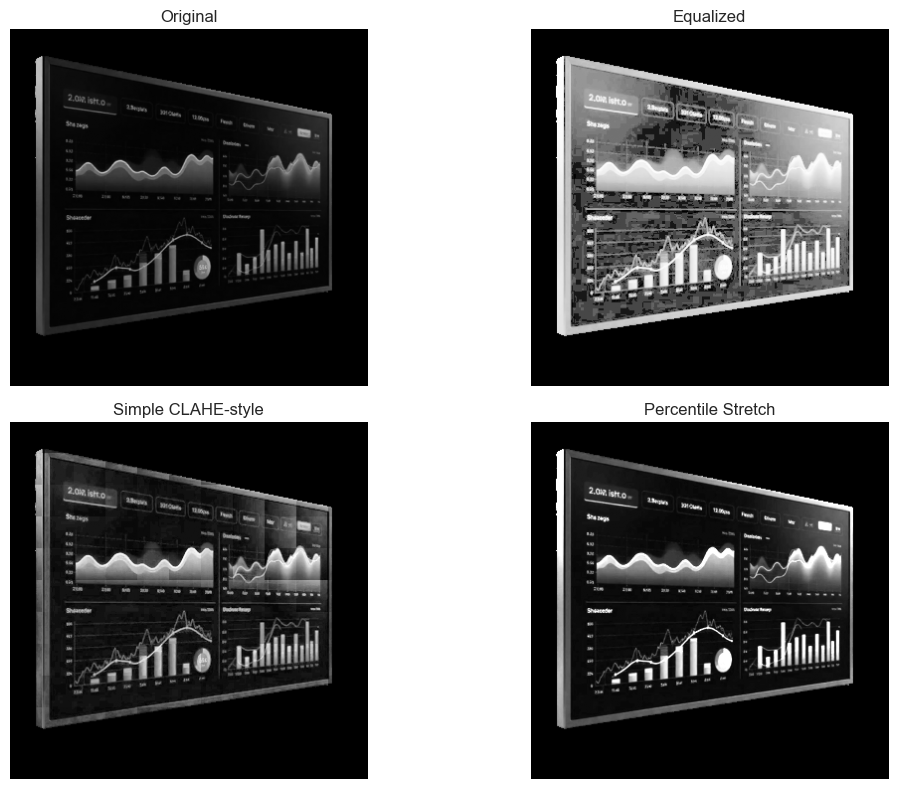

In [15]:
def rms_contrast(gray):
    return gray.astype(np.float64).std()

def entropy(gray):
    hist = compute_histogram(gray).astype(np.float64)
    p = hist / hist.sum()
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

candidates = {
    "Original": sample_gray,
    "Equalized": equalized,
    "Simple CLAHE-style": clahe_like,
    "Percentile Stretch": stretched_pct,
}

print("Quality indicators (higher is not always better, but useful for comparison):")
for name, img in candidates.items():
    print(
        f"{name:20s} | RMS contrast: {rms_contrast(img):7.2f} | Entropy: {entropy(img):6.3f}"
    )

best_name = max(candidates, key=lambda k: rms_contrast(candidates[k]))
print(f"\nHighest RMS contrast in this demo: {best_name}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, img) in zip(axes.ravel(), candidates.items()):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Final Recap

You have now covered the main histogram processing ideas:

1. Histogram, PDF, and CDF interpretation
2. Brightness, contrast, and gamma transforms
3. Contrast stretching
4. Global equalization
5. Local equalization idea (CLAHE style)
6. Color histogram handling
7. Histogram matching
8. Otsu thresholding
9. 2D color histogram analysis

## Practice Tasks

1. Replace `sample_path` with another image from `images/` and repeat all steps.
2. Try different `tile_size` and `clip_limit` values in `simple_clahe`.
3. Apply histogram matching between two different real images.
4. Combine denoising + histogram enhancement and compare results.
5. Add your own notes under each section with observations.

This notebook is your histogram processing playground. Explore and modify it.